In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/taptap_reviews_cleaned.csv")
print(f"总数: {len(df)}")
print(f"字段: {list(df.columns)}")
df.head(3)

In [2]:
daily = df.groupby('created_date').size().sort_index()
print(f"日均评论: {daily.mean():.1f}")
print(f"最高日: {daily.idxmax()} ({daily.max()}条)")
print(f"最低日: {daily.idxmin()} ({daily.min()}条)")
print(f"评论覆盖天数: {len(daily)}")

日均评论: 12.0
最高日: 2026-07-16 (314条)
最低日: 2022-03-16 (1条)
评论覆盖天数: 186


score
1    379
2    385
3    341
4    401
5    717
Name: count, dtype: int64

均分: 3.31
1-2星占比: 34.4%
4-5星占比: 50.3%
3星占比: 15.3%


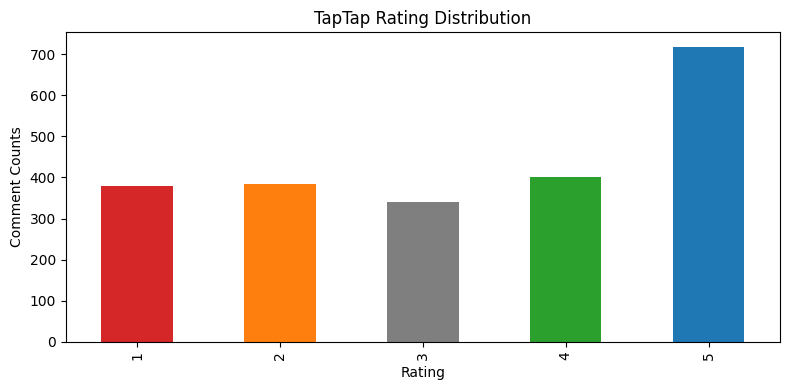

In [5]:
score_dist = df['score'].value_counts().sort_index()
print(score_dist)
print(f"\n均分: {df['score'].mean():.2f}")
print(f"1-2星占比: {(df['score']<=2).mean():.1%}")
print(f"4-5星占比: {(df['score']>=4).mean():.1%}")
print(f"3星占比: {(df['score']==3).mean():.1%}")

# 简单画图
fig, ax = plt.subplots(figsize=(8, 4))
score_dist.plot(kind='bar', color=['#d62728','#ff7f0e','#7f7f7f','#2ca02c','#1f77b4'], ax=ax)
ax.set_title('TapTap Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Comment Counts')
plt.tight_layout()
plt.savefig('eda_score_dist.png', dpi=100)
plt.show()

In [6]:
version_stats = df.groupby('version').agg(
    评论数=('review_id', 'count'),
    均分=('score', 'mean'),
    差评率=('score', lambda x: (x<=2).mean()),
    好评率=('score', lambda x: (x>=4).mean()),
    互动量均值=('ups', 'mean'),
).round(2).sort_index()

print(version_stats)

         评论数    均分   差评率   好评率   互动量均值
version                               
1.0公测    987  2.80  0.47  0.32   28.96
1.1新潮起    70  3.57  0.17  0.59   26.94
1.2春晓时   119  4.14  0.13  0.77    9.93
1.3寻遗散记  972  3.74  0.25  0.65    2.67
pre-测试    31  3.00  0.48  0.45  282.52
全面测试期     44  2.89  0.48  0.36   92.82


各版本评分占比:
score        1      2      3      4      5
version                                   
1.0公测    0.196  0.272  0.209  0.184  0.140
1.1新潮起   0.057  0.114  0.243  0.371  0.214
1.2春晓时   0.034  0.092  0.101  0.244  0.529
1.3寻遗散记  0.162  0.085  0.100  0.160  0.493
pre-测试   0.355  0.129  0.065  0.065  0.387
全面测试期    0.227  0.250  0.159  0.136  0.227


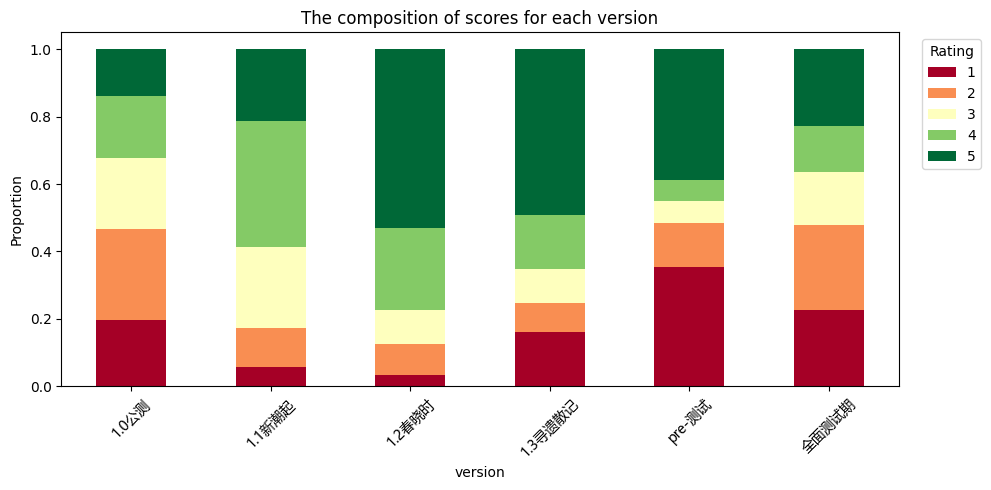

In [8]:
cross = df.groupby(['version', 'score']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0)
print("各版本评分占比:")
print(cross_pct.round(3))

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
cross_pct.plot(kind='bar', stacked=True, ax=ax, 
               colormap='RdYlGn')
ax.set_title('The composition of scores for each version')
ax.set_ylabel('Proportion')
ax.legend(title='Rating', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45, fontproperties='Microsoft YaHei')
plt.tight_layout()
plt.savefig('eda_version_x_score.png', dpi=100)
plt.show()

In [9]:
# 每月评论量
monthly = df.groupby('created_month').agg(
    评论数=('review_id', 'count'),
    均分=('score', 'mean'),
).round(2)
print(monthly)

# 小时分布（看玩家活跃时段）
hourly = df.groupby('created_hour').size()
print(f"\n评论最活跃时段: {hourly.idxmax()}点 ({hourly.max()}条)")

               评论数    均分
created_month           
2022-03          3  4.33
2022-05          1  1.00
2023-01          1  5.00
2023-04          1  1.00
2023-05          1  1.00
2023-12          1  5.00
2024-02          1  1.00
2024-07          1  5.00
2024-12          1  5.00
2025-01          2  4.50
2025-03          2  4.00
2025-06          1  5.00
2025-11         29  2.55
2025-12         21  2.81
2026-01        803  2.77
2026-02        186  2.96
2026-03         49  3.27
2026-04        119  4.18
2026-05         25  3.68
2026-06         66  3.12
2026-07        909  3.78

评论最活跃时段: 7点 (140条)
